# Exploratory Data Analysis — Adult Census Income Dataset
COMP315 — AI Software Test & ML/Ops

This notebook explores `data/adult.csv` directly (independent of the TFX pipeline) to understand feature distributions, missing values, and correlations before/alongside the pipeline's own StatisticsGen / SchemaGen / ExampleValidator output. Use this to write the **Data Validation Report** and to motivate feature-engineering choices (e.g. why `fnlwgt` and `education` were dropped — see `adult_trainer_module.py`).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

df = pd.read_csv('data/adult.csv')
print(df.shape)
df.head()

(32561, 15)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,target
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


## 1. Data overview and dtypes

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  32561 non-null  object
 14  target          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [3]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,32561.0,NaN,NaN,NaN,38.581647,13.640433,17.0,28.0,37.0,48.0,90.0
workclass,32561,9,Private,22696,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fnlwgt,32561.0,NaN,NaN,NaN,189778.366512,105549.977697,12285.0,117827.0,178356.0,237051.0,1484705.0
education,32561,16,HS-grad,10501,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education-num,32561.0,NaN,NaN,NaN,10.080679,2.57272,1.0,9.0,10.0,12.0,16.0
marital-status,32561,7,Married-civ-spouse,14976,NaN,NaN,NaN,NaN,NaN,NaN,NaN
occupation,32561,15,Prof-specialty,4140,NaN,NaN,NaN,NaN,NaN,NaN,NaN
relationship,32561,6,Husband,13193,NaN,NaN,NaN,NaN,NaN,NaN,NaN
race,32561,5,White,27816,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sex,32561,2,Male,21790,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Missing values

The UCI Adult dataset encodes missingness as the literal string `"?"` rather than an empty cell, so `pandas.isna()` alone won't catch it — check for `"?"` explicitly. This is exactly the kind of thing worth calling out in the Data Validation Report, since TFDV/ExampleValidator treats `"?"` as a normal category unless you preprocess it into a true null first.

In [4]:
missing_mask = (df == '?') | (df == ' ?')
missing_counts = missing_mask.sum().sort_values(ascending=False)
missing_pct = (missing_counts / len(df) * 100).round(2)
pd.DataFrame({'missing_count': missing_counts, 'missing_pct': missing_pct})\
  [missing_counts > 0]

,missing_count,missing_pct
occupation,1843,5.66
workclass,1836,5.64
native-country,583,1.79


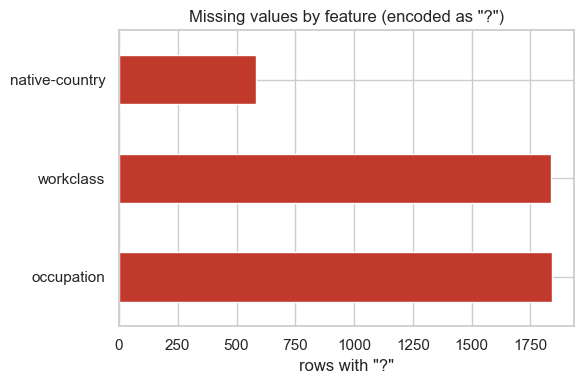

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
missing_counts[missing_counts > 0].plot(kind='barh', ax=ax, color='#c0392b')
ax.set_xlabel('rows with "?"')
ax.set_title('Missing values by feature (encoded as "?")')
plt.tight_layout()
plt.show()

**Interpretation:** `occupation`, `workclass`, and `native-country` have real missingness (roughly 5.6%, 5.6%, and 1.8% of rows respectively). All three co-occur heavily — most `occupation` gaps line up with `workclass == "?"`, which makes sense (someone who didn't report their employment class often also didn't report an occupation).

## 3. Target distribution (class imbalance)

target
<=50K    24720
>50K      7841
Name: count, dtype: int64
target
<=50K    75.9
>50K     24.1
Name: count, dtype: float64


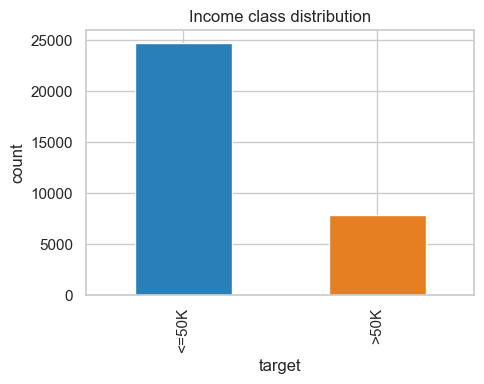

In [6]:
target_counts = df['target'].value_counts()
target_pct = (target_counts / len(df) * 100).round(1)
print(target_counts)
print(target_pct)

fig, ax = plt.subplots(figsize=(5, 4))
target_counts.plot(kind='bar', ax=ax, color=['#2980b9', '#e67e22'])
ax.set_title('Income class distribution')
ax.set_ylabel('count')
plt.tight_layout()
plt.show()

**Interpretation:** the label is imbalanced (~76% `<=50K` vs. ~24% `>50K`). Worth mentioning in the Final Reflection when discussing model limitations — plain accuracy can look good on this dataset just by predicting the majority class, which is part of why the assignment also asks you to look at AUC and sliced metrics rather than accuracy alone.

## 4. Numeric feature correlations

In [7]:
numeric_cols = ['age', 'fnlwgt', 'education-num', 'capital-gain',
                'capital-loss', 'hours-per-week']
corr = df[numeric_cols].corr()
corr

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
age,1.000000,-0.076646,0.036527,0.077674,0.057775,0.068756
fnlwgt,-0.076646,1.000000,-0.043195,0.000432,-0.010252,-0.018768
education-num,0.036527,-0.043195,1.000000,0.122630,0.079923,0.148123
capital-gain,0.077674,0.000432,0.122630,1.000000,-0.031615,0.078409
capital-loss,0.057775,-0.010252,0.079923,-0.031615,1.000000,0.054256
hours-per-week,0.068756,-0.018768,0.148123,0.078409,0.054256,1.000000


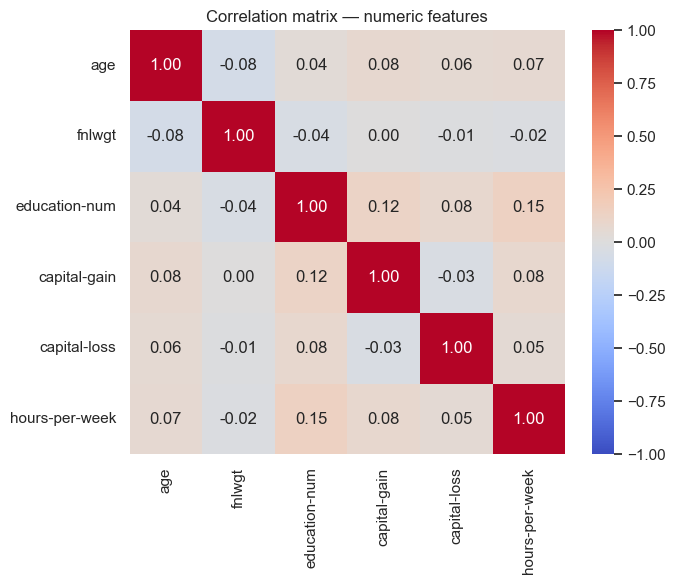

In [8]:
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            vmin=-1, vmax=1, ax=ax)
ax.set_title('Correlation matrix — numeric features')
plt.tight_layout()
plt.show()

**Interpretation:** none of the numeric features are strongly correlated with each other (all |r| well under 0.5), so multicollinearity isn't a real concern here. Note `fnlwgt` barely correlates with anything — consistent with it being a Census sampling weight rather than a substantive feature, which is why it's excluded from the model in `adult_trainer_module.py`.

## 5. Correlation of numeric features with the label

The label is categorical (`<=50K` / `>50K`), so we point-biserial correlate by encoding it 0/1 first.

In [9]:
df['target_binary'] = (df['target'].str.strip() == '>50K').astype(int)
label_corr = df[numeric_cols + ['target_binary']].corr()['target_binary']\
    .drop('target_binary').sort_values(key=abs, ascending=False)
label_corr

education-num     0.335154
age               0.234037
hours-per-week    0.229689
capital-gain      0.223329
capital-loss      0.150526
fnlwgt           -0.009463
Name: target_binary, dtype: float64

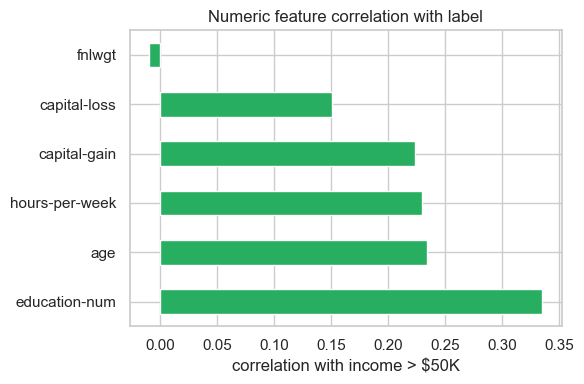

In [10]:
fig, ax = plt.subplots(figsize=(6, 4))
label_corr.plot(kind='barh', ax=ax, color='#27ae60')
ax.set_xlabel('correlation with income > $50K')
ax.set_title('Numeric feature correlation with label')
plt.tight_layout()
plt.show()

**Interpretation:** `education-num` and `age` have the strongest (positive) relationship with earning `>50K`, `hours-per-week` and `capital-gain` follow. `fnlwgt` is essentially uncorrelated with the label too — a second, independent piece of evidence (beyond what it measures) for why it doesn't belong in the model.

## 6. Categorical features vs. income

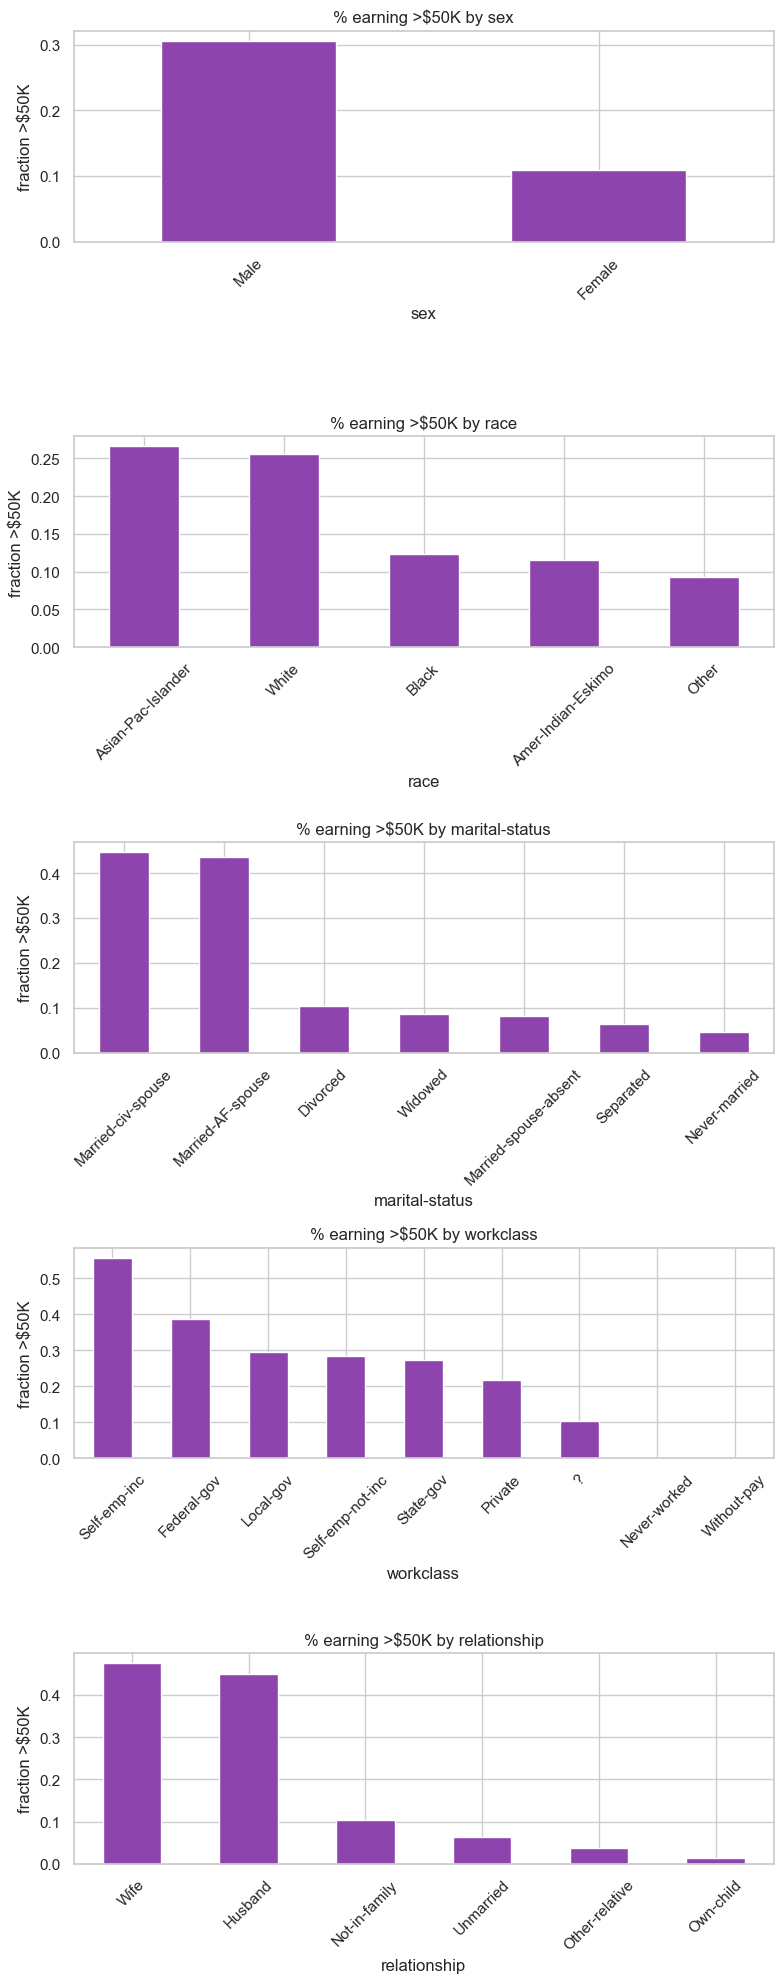

In [11]:
cat_cols = ['sex', 'race', 'marital-status', 'workclass', 'relationship']
fig, axes = plt.subplots(len(cat_cols), 1, figsize=(8, 4 * len(cat_cols)))
for ax, col in zip(axes, cat_cols):
    rate = df.groupby(col)['target_binary'].mean().sort_values(ascending=False)
    rate.plot(kind='bar', ax=ax, color='#8e44ad')
    ax.set_title(f'% earning >$50K by {col}')
    ax.set_ylabel('fraction >$50K')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

**Interpretation — write this up alongside your TFMA fairness results:** notice the gap in `>$50K` rate across `sex` and `race` here, in the raw data, *before* any modeling happens. If your TFMA slicing on `sex_xf`/`race_xf` shows a similar (or amplified) gap in the trained model's predictions, that's a strong candidate for the 'which slice has the lowest performance, and why' discussion the TFMA Fairness deliverable asks for — a real base-rate difference in the training data is a plausible root cause.

## 7. Numeric feature distributions

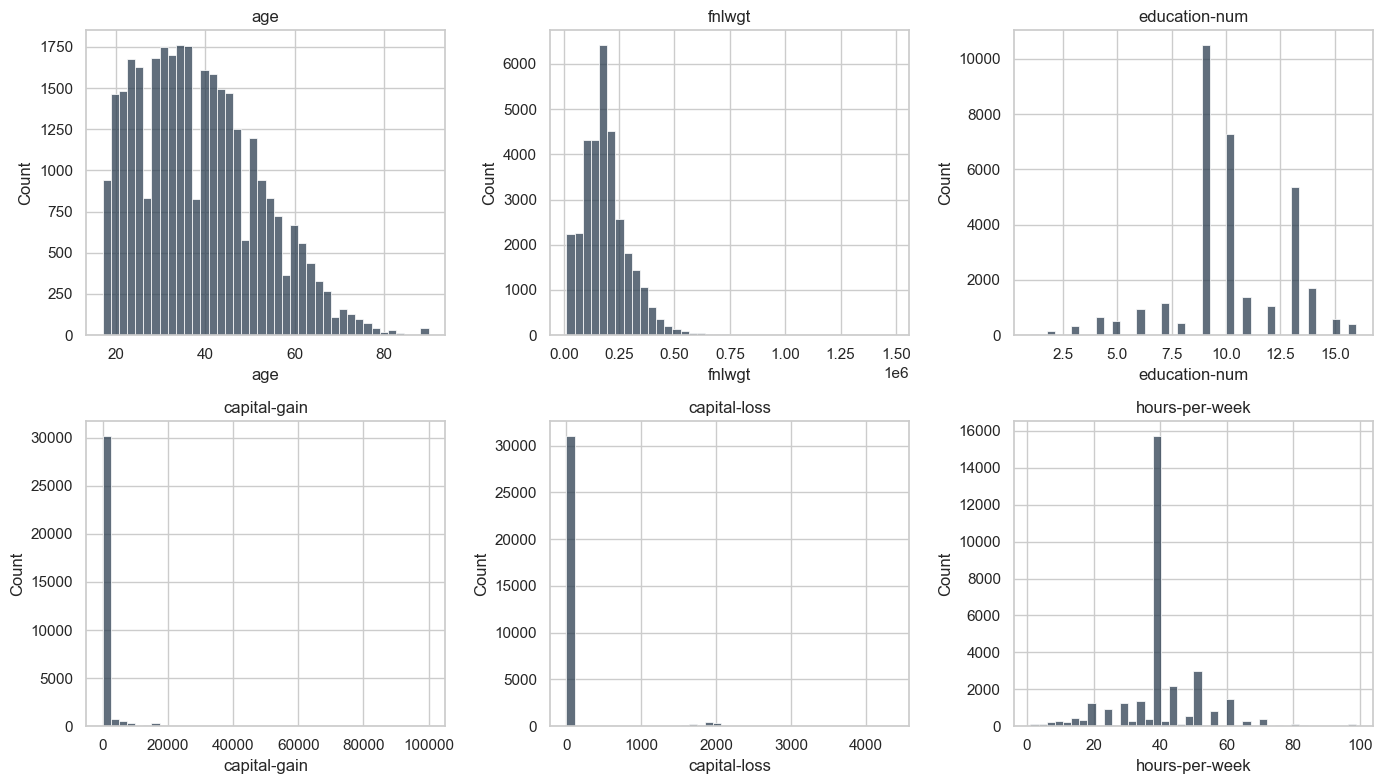

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.flat, numeric_cols):
    sns.histplot(df[col], bins=40, ax=ax, color='#2c3e50')
    ax.set_title(col)
plt.tight_layout()
plt.show()

**Interpretation:** `capital-gain` and `capital-loss` are extremely sparse/right-skewed (mostly zero, with a heavy tail) — worth a note in your reflection on whether z-score scaling (used in `preprocessing_fn`) is ideal for these two vs. a bucketized or log-transformed alternative. `age`, `education-num`, and `hours-per-week` are much more well-behaved.

## Summary for the Data Validation Report

- **Dropped entirely:** a stray, 100%-empty phantom column caused by a malformed header in the original CSV (fixed at the source).
- **Missing values (as `"?"`):** `occupation` (~5.7%), `workclass` (~5.6%), `native-country` (~1.8%) — real, not schema anomalies caused by pipeline bugs.
- **Class imbalance:** ~76%/24% split on the label.
- **Multicollinearity:** none of concern among numeric features.
- **Feature relevance:** `education-num` and `age` correlate most with the label among numeric features; `fnlwgt` correlates with essentially nothing, supporting its exclusion from the model.
- **Fairness signal:** base-rate differences in `>$50K` by `sex` and `race` exist in the raw data already, independent of the model.